In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('dataset.csv')
df.head(2)

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53766 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   uniqueID     53766 non-null  int64
 1   drugName     53766 non-null  str  
 2   condition    53471 non-null  str  
 3   review       53766 non-null  str  
 4   rating       53766 non-null  int64
 5   date         53766 non-null  str  
 6   usefulCount  53766 non-null  int64
dtypes: int64(3), str(4)
memory usage: 28.2 MB


In [4]:
df.columns

Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount'],
      dtype='str')

In [5]:
df.shape

(53766, 7)

In [6]:
df.head(5)

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4


In [7]:
import html

df['review']=df['review'].apply(html.unescape)
df['rating']=pd.to_numeric(df['rating'],errors='coerce')
df.dropna(subset=['review','rating'],inplace=True)

In [8]:
df['date']=pd.to_datetime(df['date'])
df.head(5)

C:\Users\subra\AppData\Local\Temp\ipykernel_17048\478959033.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date']=pd.to_datetime(df['date'])


,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I've tried a few antidepressants over the yea...",10,2012-02-28,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn's disease and has done very ...",8,2009-05-17,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,2017-09-29,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,2017-03-05,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,2015-10-22,4


In [9]:
df['sentiment']=df['rating'].apply(lambda x:'positive' if x>5 else 'negative')


In [10]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount,sentiment
0,163740,Mirtazapine,Depression,"""I've tried a few antidepressants over the yea...",10,2012-02-28,22,positive
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn's disease and has done very ...",8,2009-05-17,17,positive
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,2017-09-29,3,positive
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,2017-03-05,35,positive
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,2015-10-22,4,positive


In [11]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['clean_review']=df['review'].apply(clean_text)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\subra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
df.head(5)

,uniqueID,drugName,condition,review,rating,date,usefulCount,sentiment,clean_review
0,163740,Mirtazapine,Depression,"""I've tried a few antidepressants over the yea...",10,2012-02-28,22,positive,ive tried antidepressants years citalopram flu...
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn's disease and has done very ...",8,2009-05-17,17,positive,son crohns disease done well asacol complaints...
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,2017-09-29,3,positive,quick reduction symptoms
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,2017-03-05,35,positive,contrave combines drugs used alcohol smoking o...
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,2015-10-22,4,positive,birth control one cycle reading reviews type s...


In [13]:
df[['review','rating','sentiment','clean_review']].head()

,review,rating,sentiment,clean_review
0,"""I've tried a few antidepressants over the yea...",10,positive,ive tried antidepressants years citalopram flu...
1,"""My son has Crohn's disease and has done very ...",8,positive,son crohns disease done well asacol complaints...
2,"""Quick reduction of symptoms""",9,positive,quick reduction symptoms
3,"""Contrave combines drugs that were used for al...",9,positive,contrave combines drugs used alcohol smoking o...
4,"""I have been on this birth control for one cyc...",9,positive,birth control one cycle reading reviews type s...


In [14]:
df=df[['review','rating','sentiment','clean_review']]

In [15]:
df.sample()

,review,rating,sentiment,clean_review
7417,"""Today is my first day on this. I am a 42 yo f...",3,negative,today first day yo female beginning weight lbs...


In [16]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


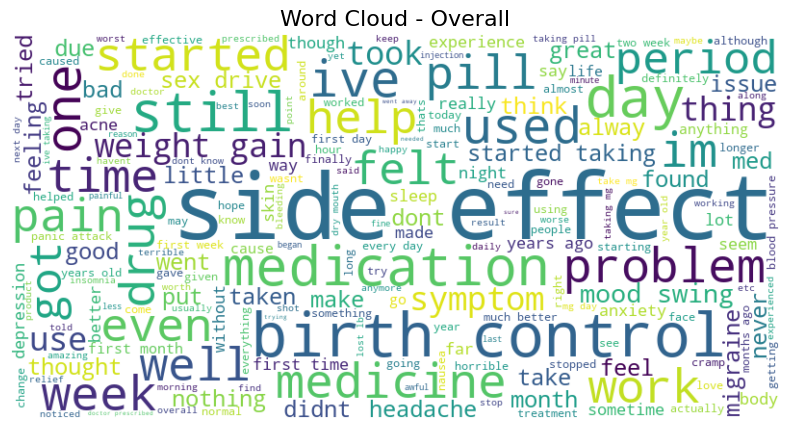

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# Overall
plot_wordcloud(' '.join(df['clean_review']), 'Word Cloud - Overall')



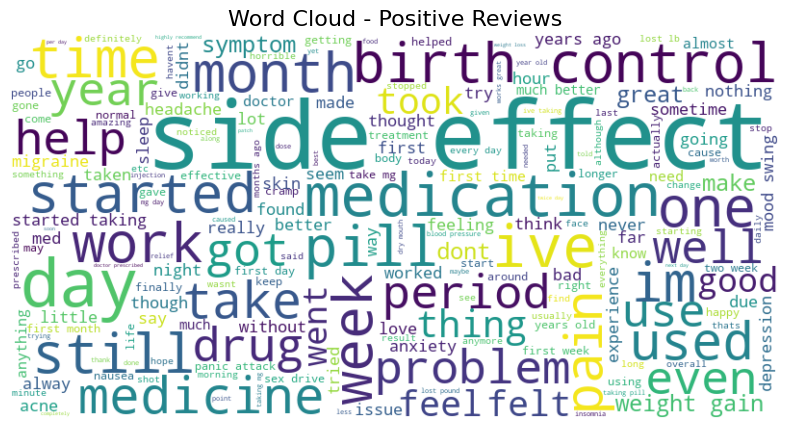

In [18]:
# positive reviews
plot_wordcloud(' '.join(df[df['sentiment'] == 'positive']['clean_review']), 'Word Cloud - Positive Reviews')

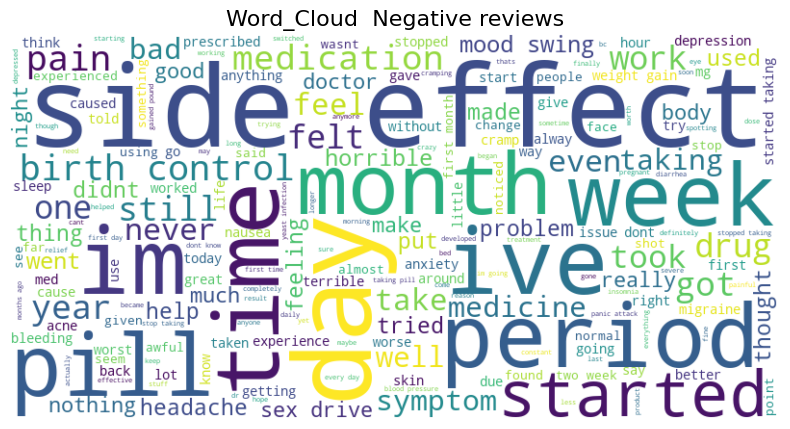

In [19]:
# negative 
plot_wordcloud(' '.join(df[df['sentiment']=='negative']['clean_review']),'Word_Cloud  Negative reviews')

In [20]:
df.sample

<bound method NDFrame.sample of                                                   review  rating sentiment  \
0      "I've tried a few antidepressants over the yea...      10  positive   
1      "My son has Crohn's disease and has done very ...       8  positive   
2                          "Quick reduction of symptoms"       9  positive   
3      "Contrave combines drugs that were used for al...       9  positive   
4      "I have been on this birth control for one cyc...       9  positive   
...                                                  ...     ...       ...   
53761  "I have taken Tamoxifen for 5 years. Side effe...      10  positive   
53762  "I've been taking Lexapro (escitaploprgram) si...       9  positive   
53763  "I'm married, 34 years old and I have no kids....       8  positive   
53764  "I was prescribed Nucynta for severe neck/shou...       1  negative   
53765                                      "It works!!!"       9  positive   

                               

In [21]:
df.shape

(53766, 4)

In [22]:
df.sentiment.value_counts()

sentiment
positive    37559
negative    16207
Name: count, dtype: int64

In [23]:
# Positive and negatuive is not balanced so that we have to do balance for making better model understanding otherwise ML model  will be biased\

# step:-1:- Separate postive and negative sentiments
positive_df=df[df['sentiment']=='positive']
negative_df=df[df['sentiment']=='negative']

# step2:- downgrade  the positve sentiment to as equal as negative sentiment
downgrade_postive = positive_df.sample(n=len(negative_df), random_state=42)

#Step-3:-Concat both downgraded postive and negative df

df_balanced=pd.concat([downgrade_postive,negative_df])

# Shuffle the dataset
df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

In [24]:
df.sentiment.value_counts()

sentiment
positive    16207
negative    16207
Name: count, dtype: int64

In [25]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import re

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X=tfidf.fit_transform(df['clean_review']) #converting text to numbers
y=df['sentiment']

In [27]:
#Train the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=43,
    stratify=y
)

In [28]:
#Fit in the model
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
## Prediction
y_predct=model.predict(X_test)

In [30]:
y_predct

array(['negative', 'negative', 'positive', ..., 'negative', 'negative',
       'negative'], shape=(6483,), dtype=object)

In [31]:
## Evaluation
print("classification_report",classification_report(y_test,y_predct))
print("confusion_matrix",confusion_matrix(y_test,y_predct))

classification_report               precision    recall  f1-score   support

    negative       0.79      0.80      0.79      3242
    positive       0.80      0.78      0.79      3241

    accuracy                           0.79      6483
   macro avg       0.79      0.79      0.79      6483
weighted avg       0.79      0.79      0.79      6483

confusion_matrix [[2602  640]
 [ 706 2535]]


In [32]:
#Accuracy
accuracy=accuracy_score(y_test,y_predct)
print("Accuracy:",accuracy)

Accuracy: 0.7923800709548049


In [33]:
import joblib

In [34]:
joblib.dump(model,'sentiment_analysis_model.pkl')
joblib.dump(tfidf,'tfidf_vectorizer.pkl')


['tfidf_vectorizer.pkl']